<a href="https://colab.research.google.com/github/LaurenMitchell-tech/uvvisml/blob/main/notebooks/Multitask_Multicomponent_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Run to allow gpu use. Skip if using cpu. Usually takes a few minutes.
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 90.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 105.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 51.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 39.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 99.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    try:
        import chemprop
    except ImportError:
        !git clone https://github.com/chemprop/chemprop.git
        %cd chemprop
        !pip install .
        %cd examples

from lightning import pytorch as pl
import torch
import numpy as np
import pandas as pd
from pathlib import Path

import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from chemprop import data, featurizers, models, nn
from chemprop.nn import metrics
from chemprop.models import multi

Cloning into 'chemprop'...
remote: Enumerating objects: 25691, done.
remote: Counting objects: 100% (434/434), done.
remote: Compressing objects: 100% (333/333), done.
remote: Total 25691 (delta 311), reused 101 (delta 100), pack-reused 25257 (from 3)
Receiving objects: 100% (25691/25691), 877.41 MiB | 18.78 MiB/s, done.
Resolving deltas: 100% (18415/18415), done.
Updating files: 100% (337/337), done.
/content/chemprop
Processing /content/chemprop
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
chemprop_dir = Path.cwd().parent
input_path = chemprop_dir / "examples" / "all_optical_data_including_duplicates.csv"
smiles_columns = ['smiles', 'solvent']
target_columns = ['absorption_max','emission_max']

df_input = pd.read_csv(input_path, usecols=['smiles', 'solvent', 'absorption_max','emission_max'])
df_input.dropna(inplace=True)
smiss = df_input.loc[:, smiles_columns].values
ys = df_input.loc[:, target_columns].values

datapoints = [[data.MoleculeDatapoint.from_smi(smis[0], y) for smis, y in zip(smiss, ys)]]
datapoints += [[data.MoleculeDatapoint.from_smi(smis[i]) for smis in smiss] for i in range(1, len(smiles_columns))]

In [ ]:
df_input

,smiles,solvent,absorption_max,emission_max
0,COC(=O)c1ccn2cc(-c3ccc(OC)cc3)nc2c1,CS(C)=O,355.0,427.0
1,COC(=O)c1ccn2c(N)c(-c3ccc(OC)cc3)nc2c1,CS(C)=O,426.0,520.0
2,COC(=O)c1ccn2c(NC3CCCCC3)c(-c3ccc(OC)cc3)nc2c1,CS(C)=O,387.0,528.0
3,COC(=O)c1cccc2nc(-c3ccc(OC)cc3)c(NC3CCCCC3)n12,CS(C)=O,355.0,627.0
4,COc1ccc(-c2nc3ncccn3c2NC2CCCCC2)cc1,CS(C)=O,365.0,560.0
...,...,...,...,...
62971,CN(CCO)c1ccc(/C=C/C(=O)c2ccc(NC(=O)c3cc(F)cc(C...,CS(C)=O,432.0,563.0
62972,CCCCC1(CCCC)c2cc(C(=O)O)ccc2-c2ccc(N(c3ccccc3)...,CCO,369.0,534.0
62973,c1ccc(-c2cc(-c3ccc(N(c4ccccc4)c4ccccc4)cc3)cc(...,CCCCCC,354.0,393.0
62974,CCCCn1c2ccc(/C=C(\C#N)c3ccc([N+](=O)[O-])cc3)c...,c1ccccc1,409.0,505.0


In [ ]:
#multicomponent code
component_to_split_by = 0 # index of the component to use for structure based splits
mols = [d.mol for d in datapoints[component_to_split_by]]

train_indices, val_indices, test_indices = data.make_split_indices(mols, "random", (0.8, 0.1, 0.1))
train_data, val_data, test_data = data.split_data_by_indices(
    datapoints, train_indices, val_indices, test_indices
)

In [ ]:
#Display test set
test_indices = [idx for sublist in test_indices for idx in sublist]
df_test = df_input.iloc[test_indices].reset_index(drop=True)
df_test

,smiles,solvent,absorption_max,emission_max
0,Cc1ccc(C2=C3C(=[Cl+])C(Cl)=C(Cl)N3[B-](F)(F)n3...,CO,531.0,544.0
1,c1ccc2c(c1)Sc1ccccc1N2c1ccc2c(c1)C1(CCCC1)c1cc...,Cc1ccccc1,308.0,491.0
2,CN(CCO[Si](C)(C)C(C)(C)C)c1ccc(-c2ccc(C=C(C#N)...,C1CCOC1,470.0,578.0
3,CC1CC=C(c2ccc(-c3ccc(C#N)s3)s2)CC1,OCCOCCO,366.0,451.0
4,O=C(c1ccc(N(c2ccccc2)c2ccccc2)cc1)[C@H]1[C@H](...,CCO,368.0,515.0
...,...,...,...,...
4498,CCCCCCN(CCCCCC)c1ccc2cc3cc(C(=O)CC)ccc3cc2c1,ClC(Cl)Cl,458.0,536.0
4499,CC1=CC(C)(C)Nc2ccc3c(-c4ccc(F)c(Cl)c4)c4ccc(=[...,O,500.0,550.0
4500,c1ccc(-c2nc(-c3ccc(-c4ccc(N(c5ccccc5)c5ccccc5)...,CCOC(C)=O,351.0,456.0
4501,O=[N+]([O-])c1ccc(-c2sc(N(c3ccccc3)c3ccccc3)nc...,C1CCOC1,466.0,623.0


In [ ]:
#multicomponent code
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

train_dset = [data.MoleculeDataset(train_data[0][i], featurizer) for i in range(len(smiles_columns))]
val_dset = [data.MoleculeDataset(val_data[0][i], featurizer) for i in range(len(smiles_columns))]
test_dset = [data.MoleculeDataset(test_data[0][i], featurizer) for i in range(len(smiles_columns))]

train_mcdset = data.MulticomponentDataset(train_dset)
scaler = train_mcdset.normalize_targets()
val_mcdset = data.MulticomponentDataset(val_dset)
val_mcdset.normalize_targets(scaler)
test_mcdset = data.MulticomponentDataset(test_dset)

BATCH_SIZE = 256
train_loader = data.build_dataloader(train_mcdset, batch_size=BATCH_SIZE)
val_loader = data.build_dataloader(val_mcdset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.build_dataloader(test_mcdset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
#multicomponent code

torch.manual_seed(0) #use same random seed every time
np.random.seed(0)

mcmp = nn.MulticomponentMessagePassing(
    blocks=[nn.BondMessagePassing() for _ in range(len(smiles_columns))],
    n_components=len(smiles_columns),
)

agg = nn.MeanAggregation()

In [ ]:
#multicomponent code, could add dropout in the FFN (e.g., dropout=0.2–0.5)
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)

ffn = nn.RegressionFFN(
    n_tasks = len(target_columns),
    input_dim=mcmp.output_dim,
    output_transform=output_transform,
)

metric_list = [metrics.RMSE(), metrics.MAE()] # Only the first metric is used for training and early stopping

In [ ]:
#multicomponent code
mcmpnn = multi.MulticomponentMPNN(
    mcmp,
    agg,
    ffn,
    metrics=metric_list,
)

mcmpnn

MulticomponentMPNN(
  (message_passing): MulticomponentMessagePassing(
    (blocks): ModuleList(
      (0-1): 2 x BondMessagePassing(
        (W_i): Linear(in_features=86, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=372, out_features=300, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (tau): ReLU()
        (V_d_transform): Identity()
        (graph_transform): Identity()
      )
    )
  )
  (agg): MeanAggregation()
  (bn): Identity()
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=600, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=2, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0, 1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): Identity()
  (metrics): ModuleL

In [ ]:
#code for training a model which will be saved
checkpoint = pl.callbacks.ModelCheckpoint(
    dirpath="checkpoints/",
    monitor="val_loss",
    save_top_k=1,
    mode="min",
    filename="all_data_abs_emi"
)

early_stop = pl.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    mode="min"
)

from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.AdamW(mcmpnn.parameters(), lr=2e-4, weight_decay=1e-6)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [ ]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

In [ ]:
#multicomponent code
trainer = pl.Trainer(accelerator="auto", logger=True, callbacks=[checkpoint, early_stop], max_epochs=100, deterministic=True) #enable_checkpointing=False,

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
#multicomponent code
trainer.fit(mcmpnn, train_loader, val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ MulticomponentMessagePassing │  455 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation              │      0 │ train │     0 │
│ 2 │ bn              │ Identity                     │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN                │  180 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity                     │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList                   │      0 │ train │     0 │
└───┴─────────────────┴──────────────────────────────┴────────┴───────┴───────┘

Trainable params: 636 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 636 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/core/saving.py:365: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


In [ ]:
results = trainer.test(mcmpnn, test_loader, weights_only=False)  # weights_only=False is only required with pytorch lightning version 2.6.0 or newer

In [ ]:
#Show where model is saved
best_model_path = checkpoint.best_model_path
print(f"Best model saved at: {best_model_path}")

Best model saved at: /content/chemprop/examples/checkpoints/Deep4Chem_abs_emi.ckpt


In [ ]:
#Code for loading different model than the one just trained
path = chemprop_dir / "examples" / "CIE_model_nm.ckpt"
mcmpnn = models.multi.MulticomponentMPNN.load_from_checkpoint(path, map_location="cpu", weights_only=False)

In [ ]:
#Predict and show results compared to known data
preds = trainer.predict(mcmpnn, test_loader) #Works with mcmpnn or chemprop_model
preds_tensor = torch.cat(preds, dim=0)

preds_array = preds_tensor.detach().cpu().numpy()

columns = ['abs_pred', 'emi_pred']
df_test[columns] = preds_array

df_test

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,Chromophore,Solvent,abs FWHM (cm-1),emi FWHM (cm-1),abs_pred,emi_pred
0,CCCSc1ccc2n1[B-](F)(F)[N+]1=CC=CC1=C2c1ccccc1,CC#N,955.0,1012.0,893.125000,1100.597656
1,N#CSC1=CC2=C(c3c(Cl)cccc3Cl)c3cc(SC#N)c(NCc4cc...,CCCCCC,575.0,930.0,-31.702393,725.052734
2,COc1ccc(-n2cccc2)cc1,CC#N,6735.0,3741.7,6117.484375,3822.318848
3,COc1ccc2n1[B-](F)(F)[N+]1=CC=CC1=C2c1ccccc1,ClCCl,1173.0,1140.0,1050.415283,1023.498535
4,CCc1c(C)c2n(c1C)[B-](F)(F)[N+]1=C(NCc3ccc(OC)c...,CCOC(C)=O,1094.0,1095.0,1294.361694,1154.056030
5,Cc1c2oc3c(C)c(N)cc(C(=O)NC4OC(=O)C(C(C)C)N(C)C...,CCO,3959.1,2184.8,3924.265137,1974.837891
6,CN(C)c1ccc(C2=Cc3cccc[n+]3[B-](F)(F)O2)cc1,COC(C)=O,3832.9,3315.6,3699.886963,3066.294189
7,COC1=[N+]2C(=C(c3ccccc3)c3ccc(OC)n3[B-]2(F)F)C...,CC#N,2119.0,1519.0,2041.909546,1384.369629
8,N#CSC1=CC2=C(c3ccccc3)c3cc(SC#N)c(N4CCOCC4)n3[...,ClCCl,780.0,937.0,1551.986206,1131.441895
9,CN(C)c1ccc(C(=O)c2ccccc2)cc1,CS(C)=O,4396.4,5005.0,4005.104980,5104.208984


In [ ]:
def plot_and_save(true_values=str, preds=str, model=str, value_type=str, save_path=str):

  '''
  true_values: name of column containing experimental x or y values
  preds: name of column containing predicted x or y values
  model: name of model used to make prediction
  save_path: path where figure will be saved

  plots a parity plot and saves the figure to the specified path
  '''

  true_ys = df_test[true_values].tolist()
  preds_y = df_test[preds].tolist()

  fig = plt.figure(figsize=(8,5))
  plt.scatter(true_ys, preds_y, color='red', marker='o', label='Parity Plot')
  ax = plt.gca()
  lims = ax.get_xlim()
  ax.plot(lims, lims, color='black')
  plt.legend()
  plt.xlabel('Experimental')
  plt.ylabel('Predicted')
  title = 'Parity Plot of ' + model + ' ' + value_type + ' Values'
  plt.title(title)
  plt.grid(True)

  with open(save_path, "wb") as f:
      pickle.dump(fig, f)

  plt.show()

  print('Plot saved as: ' + save_path)

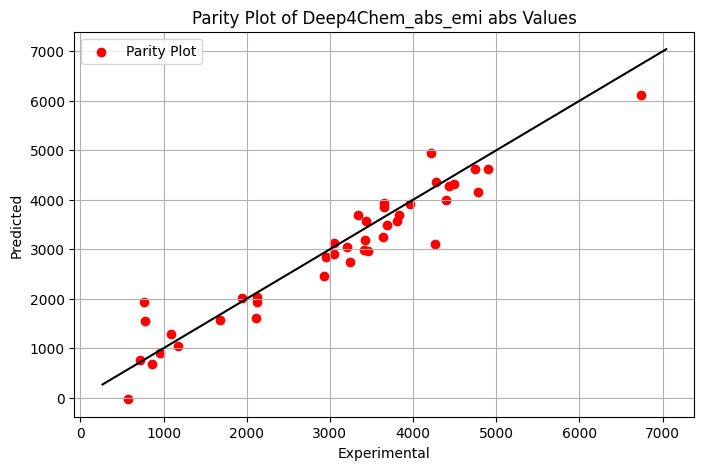

Plot saved as: Abs_Parity_abs_emi_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plot_and_save('abs FWHM (cm-1)', 'abs_pred', 'Deep4Chem_abs_emi', 'abs', 'Abs_Parity_abs_emi_model.pkl')
files.download('Abs_Parity_abs_emi_model.pkl')

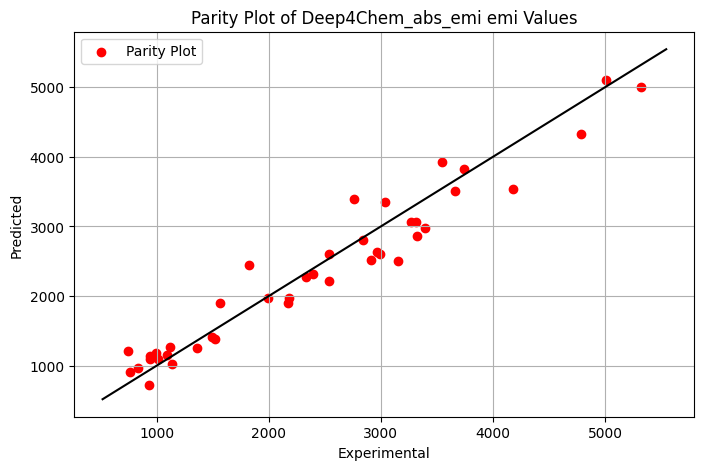

Plot saved as: Emi_Parity_abs_emi_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plot_and_save('emi FWHM (cm-1)', 'emi_pred', 'Deep4Chem_abs_emi', 'emi', 'Emi_Parity_abs_emi_model.pkl')
files.download('Emi_Parity_abs_emi_model.pkl')